In [1]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
@dataclass
class ArchieParams:
    """
    Parameters for Archie's law.

    Attributes
    ----------
    a : float
        Tortuosity factor.
    m : float
        Cementation exponent.
    c : float
        Saturation-related exponent.
    f : float, optional
        Saturation factor (default = 1.0, fully saturated).
    """
    a: float
    m: float
    c: float
    f: float = 1.0


def read_well_sec(
    well_filepath: str,
    vadose_thickness: float,
    depth_column: str = "Vertical Position m",
    sec_column: str = "Corrected sp Cond [µS/cm]",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Read well log data from a CSV file and convert electrical conductivity (SEC)
    to fluid resistivity.

    Parameters
    ----------
    well_filepath : str
        Path to the CSV file containing the well log.
    vadose_thickness : float
        Thickness of the vadose zone (m) to be added to the measured depth
        before converting to negative depths.
    depth_column : str
        Column storing the depth values.
    sec_column : str
        Column storing the electrical conductivity values (µS/cm).

    Returns
    -------
    depth : np.ndarray
        Depth values (m), negative downward.
    fluid_res : np.ndarray
        Fluid resistivity values (Ohm·m).
    """

    df = pd.read_csv(well_filepath)

    raw_depth = pd.to_numeric(df[depth_column], errors="coerce").to_numpy()
    depth = -(raw_depth + vadose_thickness)

    sec_raw = pd.to_numeric(df[sec_column], errors="coerce").to_numpy()

    # Convert µS/cm → S/m
    sec_S_per_m = sec_raw * (1e2 / 1e6)

    # Convert to resistivity (Ohm·m)
    fluid_res = 1.0 / sec_S_per_m

    return depth, fluid_res


def clean_well_log(
    depth_raw: np.ndarray,
    res_raw: np.ndarray,
    depth_min: float = -70.0,
    depth_max: float = 0.0,
    depth_step: float = 0.1,
    window: float = 0.05,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Clean and smooth well log fluid resistivity values.

    This function:
    - Defines a regular depth grid.
    - Applies a rolling depth average (within ±window).
    - Fills deeper-than-logged depths with a brine resistivity.
    - Fills shallower-than-logged depths with the mean of the shallowest 50 raw values.
    - Fills remaining internal gaps by 1D interpolation.

    Parameters
    ----------
    depth_raw : np.ndarray
        1D array of original depths (m), typically negative downward.
    res_raw : np.ndarray
        1D array of original fluid resistivity values (Ohm·m) at `depth_raw`.
    depth_min : float, optional
        Minimum depth (m) of the regular grid (default is -70.0).
    depth_max : float, optional
        Maximum depth (m) of the regular grid (default is 0.0).
    depth_step : float, optional
        Depth step (m) of the regular grid (default is 0.1).
    window : float, optional
        Half-window length (m) used for the rolling average around each grid depth.

    Returns
    -------
    depth : np.ndarray
        1D array of regularly spaced depths (m).
    res_clean : np.ndarray
        1D array of cleaned, smoothed fluid resistivity values (Ohm·m).
    """
    depth_raw = np.asarray(depth_raw, dtype=float)
    res_raw = np.asarray(res_raw, dtype=float)

    # Temporary fixed brine resistivity; later this can be parameterized
    res_brine = 1.0 / (54334.0 * (100.0 / 1000000.0))

    depth = np.arange(depth_min, depth_max + depth_step / 2.0, depth_step)
    res = np.full_like(depth, np.nan, dtype=float)

    for i, d in enumerate(depth):
        d1 = d - window
        d2 = d + window
        mask = (depth_raw >= d1) & (depth_raw < d2)
        if np.any(mask):
            res[i] = np.nanmean(res_raw[mask])

    mask_deep = depth < np.min(depth_raw)
    res[mask_deep] = res_brine

    mask_shallow = depth > np.max(depth_raw)
    if res_raw.size >= 50:
        shallow_mean = np.nanmean(res_raw[:50])
    else:
        shallow_mean = np.nanmean(res_raw)
    res[mask_shallow] = shallow_mean

    valid = ~np.isnan(res)
    if np.sum(valid) < 2:
        res_clean = res
    else:
        res_clean = np.interp(depth, depth[valid], res[valid])

    return depth, res_clean


def load_resipy_model(dat_filepath: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load resistivity model data from a DAT file without headers.

    Expected column order in the file:
    1) x
    2) depth
    3) resist
    4) resistlog10

    The fourth column ('resistlog10') is read but not used.

    Parameters
    ----------
    dat_filepath : str
        Path to the DAT file.

    Returns
    -------
    x : np.ndarray
        1D array of x-coordinates (m).
    z : np.ndarray
        1D array of depth coordinates (m).
    ert_res : np.ndarray
        1D array of resistivity values (Ohm·m).
    """
    cols = ["x", "depth", "resist", "resistlog10"]

    df = pd.read_csv(
        dat_filepath,
        sep=r"\s+",
        header=None,
        names=cols,
        engine="python",
    )

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
    df["resist"] = pd.to_numeric(df["resist"], errors="coerce")

    df = df.dropna(subset=["x", "depth", "resist"])

    x = df["x"].to_numpy(dtype=float)
    z = df["depth"].to_numpy(dtype=float)
    ert_res = df["resist"].to_numpy(dtype=float)

    return x, z, ert_res


def porosity_section(
    x: np.ndarray,
    z: np.ndarray,
    ert_res: np.ndarray,
    wellz: np.ndarray,
    fluid_res: np.ndarray,
    archie: ArchieParams,
) -> np.ndarray:
    """
    Compute porosity from ERT resistivity using Archie's law and a well log
    of fluid resistivity.

    Archie's law is applied as:

        phi = [ (a / f^c) * (R_w / R_t) ]^(1/m)

    where
        phi  : porosity (fraction)
        a    : tortuosity factor
        m    : cementation exponent
        c    : saturation-related exponent
        f    : saturation factor
        R_w  : fluid resistivity from the well log (Ohm·m)
        R_t  : bulk resistivity from ERT (Ohm·m)

    Parameters
    ----------
    x : np.ndarray
        1D array of x-coordinates (m).
    z : np.ndarray
        1D array of z-coordinates (m).
    ert_res : np.ndarray
        1D array of ERT resistivity values (Ohm·m).
    wellz : np.ndarray
        1D array of depths (m) for the well log.
    fluid_res : np.ndarray
        1D array of fluid resistivity values (Ohm·m) at `wellz`.
    archie : ArchieParams
        Object containing Archie's law parameters.

    Returns
    -------
    phi : np.ndarray
        1D array of porosity values (fraction) corresponding to each ERT cell.
    """
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)
    ert_res = np.asarray(ert_res, dtype=float)
    wellz = np.asarray(wellz, dtype=float)
    fluid_res = np.asarray(fluid_res, dtype=float)

    sort_idx = np.argsort(wellz)
    wellz_sorted = wellz[sort_idx]
    fluid_sorted = fluid_res[sort_idx]

    fluid_at_z = np.interp(z, wellz_sorted, fluid_sorted)

    phi = np.full_like(ert_res, np.nan, dtype=float)

    valid = ert_res > 0.0
    if np.any(valid):
        ratio = fluid_at_z[valid] / ert_res[valid]
        factor = archie.a / (archie.f ** archie.c)
        phi[valid] = (factor * ratio) ** (1.0 / archie.m)

    return phi


def calc_porosity_section(
    well_log_path: str,
    vadose_thickness: float,
    resipy_dat_path: str,
    archie: ArchieParams,
    plot: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    High-level function that:
    1) Reads and cleans the well log,
    2) Loads the ERT model from a DAT file,
    3) Computes porosity using Archie's law,
    4) Optionally plots fluid resistivity, ERT resistivity, and porosity sections.

    Parameters
    ----------
    well_log_path : str
        Path to the CSV file containing the well log (fluid conductivity).
    vadose_thickness : float
        Thickness of the vadose zone (m) to be added to measured depths.
    resipy_dat_path : str
        Path to the DAT output file with resistivity model.
    archie : ArchieParams
        Object containing Archie's law parameters.
    plot : bool, optional
        If True, generate a figure with seven subplots.

    Returns
    -------
    x : np.ndarray
        1D array of x-coordinates (m) from the ERT model.
    z : np.ndarray
        1D array of z-coordinates (m) from the ERT model.
    ert_res : np.ndarray
        1D array of ERT resistivity values (Ohm·m).
    phi : np.ndarray
        1D array of porosity values (fraction) computed from Archie's law.
    """
    # 1) Read and clean well log
    wellz, fluid_res = read_well_sec(well_log_path, vadose_thickness)
    wellz_clean, fluid_res_clean = clean_well_log(wellz, fluid_res)

    # 2) Load ERT model
    x, z, ert_res = load_resipy_model(resipy_dat_path)

    # 3) Compute porosity
    phi = porosity_section(
        x=x,
        z=z,
        ert_res=ert_res,
        wellz=wellz_clean,
        fluid_res=fluid_res_clean,
        archie=archie,
    )

    # 4) Plot results if requested
    if plot:
        fig, axes = plt.subplots(7, 1, figsize=(12, 14))

        # --- Fluid resistivity (raw vs cleaned) ---
        ax1 = axes[0]
        ax1.plot(fluid_res, wellz, "k.", label="Raw")
        ax1.plot(fluid_res_clean, wellz_clean, "r-", linewidth=2, label="Cleaned")
        ax1.set_title("Fluid resistivity (Ohm·m)")
        ax1.set_xlabel("Resistivity (Ohm·m)")
        ax1.set_ylabel("Depth (m)")
        ax1.tick_params(axis="both", direction="in", labelsize=8)
        ax1.legend()

        # --- ERT resistivity section ---
        ax2 = axes[1]
        sc2 = ax2.scatter(
            x,
            z,
            s=30,
            c=ert_res,
            cmap="jet",
            vmin=0,
            vmax=1000,
        )
        ax2.set_title("ERT resistivity (Ohm·m)")
        ax2.set_xlabel("Distance (m)")
        ax2.set_ylabel("Depth (m)")
        ax2.set_aspect("equal")
        ax2.tick_params(axis="both", direction="in", labelsize=8)

        divider2 = make_axes_locatable(ax2)
        cax2 = divider2.append_axes("right", size="3%", pad=0.1)
        cbar2 = fig.colorbar(sc2, cax=cax2)
        cbar2.ax.tick_params(length=0, labelsize=7)

        # --- Porosity section ---
        ax3 = axes[2]
        sc3 = ax3.scatter(
            x,
            z,
            s=30,
            c=phi,
            cmap="jet",
            vmin=0.0,
            vmax=0.2,
        )
        ax3.set_title(
            f"Porosity (fraction) — Archie a={archie.a}, m={archie.m}, c={archie.c}, f={archie.f}"
        )
        ax3.set_xlabel("Distance (m)")
        ax3.set_ylabel("Depth (m)")
        ax3.set_aspect("equal")
        ax3.tick_params(axis="both", direction="in", labelsize=8)

        divider3 = make_axes_locatable(ax3)
        cax3 = divider3.append_axes("right", size="3%", pad=0.1)
        cbar3 = fig.colorbar(sc3, cax=cax3)
        cbar3.ax.tick_params(length=0, labelsize=7)

        # --- ERT resistivity (linear scale, viridis, 2–98 percentiles) ---
        ax4 = axes[3]

        valid_ert = np.isfinite(ert_res)
        vmin_ert = np.nanpercentile(ert_res[valid_ert], 2)
        vmax_ert = np.nanpercentile(ert_res[valid_ert], 98)

        sc4 = ax4.scatter(
            x,
            z,
            s=30,
            c=ert_res,
            cmap="viridis",
            vmin=vmin_ert,
            vmax=vmax_ert,
        )

        ax4.set_title("ERT resistivity (Ohm·m) — Linear scale (2–98 percentile)")
        ax4.set_xlabel("Distance (m)")
        ax4.set_ylabel("Depth (m)")
        ax4.set_aspect("equal")
        ax4.tick_params(axis="both", direction="in", labelsize=8)

        divider4 = make_axes_locatable(ax4)
        cax4 = divider4.append_axes("right", size="3%", pad=0.1)
        cbar4 = fig.colorbar(sc4, cax=cax4)
        cbar4.set_label("Resistivity (Ohm·m)")
        cbar4.ax.tick_params(length=0, labelsize=7)

        # --- ERT resistivity (log scale, viridis, 2–98 percentiles) ---
        ax5 = axes[4]

        ert_plot = np.where(ert_res > 0, ert_res, np.nan)
        valid_ert = np.isfinite(ert_plot)

        vmin_ert = np.nanpercentile(ert_plot[valid_ert], 2)
        vmax_ert = np.nanpercentile(ert_plot[valid_ert], 98)

        sc5 = ax5.scatter(
            x,
            z,
            s=30,
            c=ert_plot,
            cmap="viridis",
            norm=LogNorm(vmin=vmin_ert, vmax=vmax_ert),
        )

        ax5.set_title("ERT resistivity (Ohm·m) — Log scale (2–98 percentile)")
        ax5.set_xlabel("Distance (m)")
        ax5.set_ylabel("Depth (m)")
        ax5.set_aspect("equal")
        ax5.tick_params(axis="both", direction="in", labelsize=8)

        divider5 = make_axes_locatable(ax5)
        cax5 = divider5.append_axes("right", size="3%", pad=0.1)
        cbar5 = fig.colorbar(sc5, cax=cax5)
        cbar5.set_label("Resistivity (Ohm·m)")
        cbar5.ax.tick_params(length=0, labelsize=7)

        # --- Porosity (linear scale, viridis, 2–98 percentiles) ---
        ax6 = axes[5]

        phi_plot = np.where(np.isfinite(phi), phi, np.nan)
        valid_phi = np.isfinite(phi_plot)

        vmin_phi = np.nanpercentile(phi_plot[valid_phi], 2)
        vmax_phi = np.nanpercentile(phi_plot[valid_phi], 98)

        sc6 = ax6.scatter(
            x,
            z,
            s=30,
            c=phi_plot,
            cmap="viridis",
            vmin=vmin_phi,
            vmax=vmax_phi,
        )

        ax6.set_title("Porosity (fraction) — Linear scale (2–98 percentile)")
        ax6.set_xlabel("Distance (m)")
        ax6.set_ylabel("Depth (m)")
        ax6.set_aspect("equal")
        ax6.tick_params(axis="both", direction="in", labelsize=8)

        divider6 = make_axes_locatable(ax6)
        cax6 = divider6.append_axes("right", size="3%", pad=0.1)
        cbar6 = fig.colorbar(sc6, cax=cax6)
        cbar6.set_label("Porosity (fraction)")
        cbar6.ax.tick_params(length=0, labelsize=7)

        # --- Porosity (clipped to physical range, viridis) ---
        ax7 = axes[6]

        phi_max_display = 0.9

        phi_phys = np.where(np.isfinite(phi), phi, np.nan)
        phi_phys = np.clip(phi_phys, 0.0, phi_max_display)

        sc7 = ax7.scatter(
            x,
            z,
            s=30,
            c=phi_phys,
            cmap="viridis",
            vmin=0.0,
            vmax=phi_max_display,
        )

        ax7.set_title(f"Porosity (fraction) — Clipped to 0–{phi_max_display}")
        ax7.set_xlabel("Distance (m)")
        ax7.set_ylabel("Depth (m)")
        ax7.set_aspect("equal")
        ax7.tick_params(axis="both", direction="in", labelsize=8)

        divider7 = make_axes_locatable(ax7)
        cax7 = divider7.append_axes("right", size="3%", pad=0.1)
        cbar7 = fig.colorbar(sc7, cax=cax7)
        cbar7.set_label("Porosity (fraction)")
        cbar7.ax.tick_params(length=0, labelsize=7)

        plt.tight_layout()
        plt.show()

    return x, z, ert_res, phi

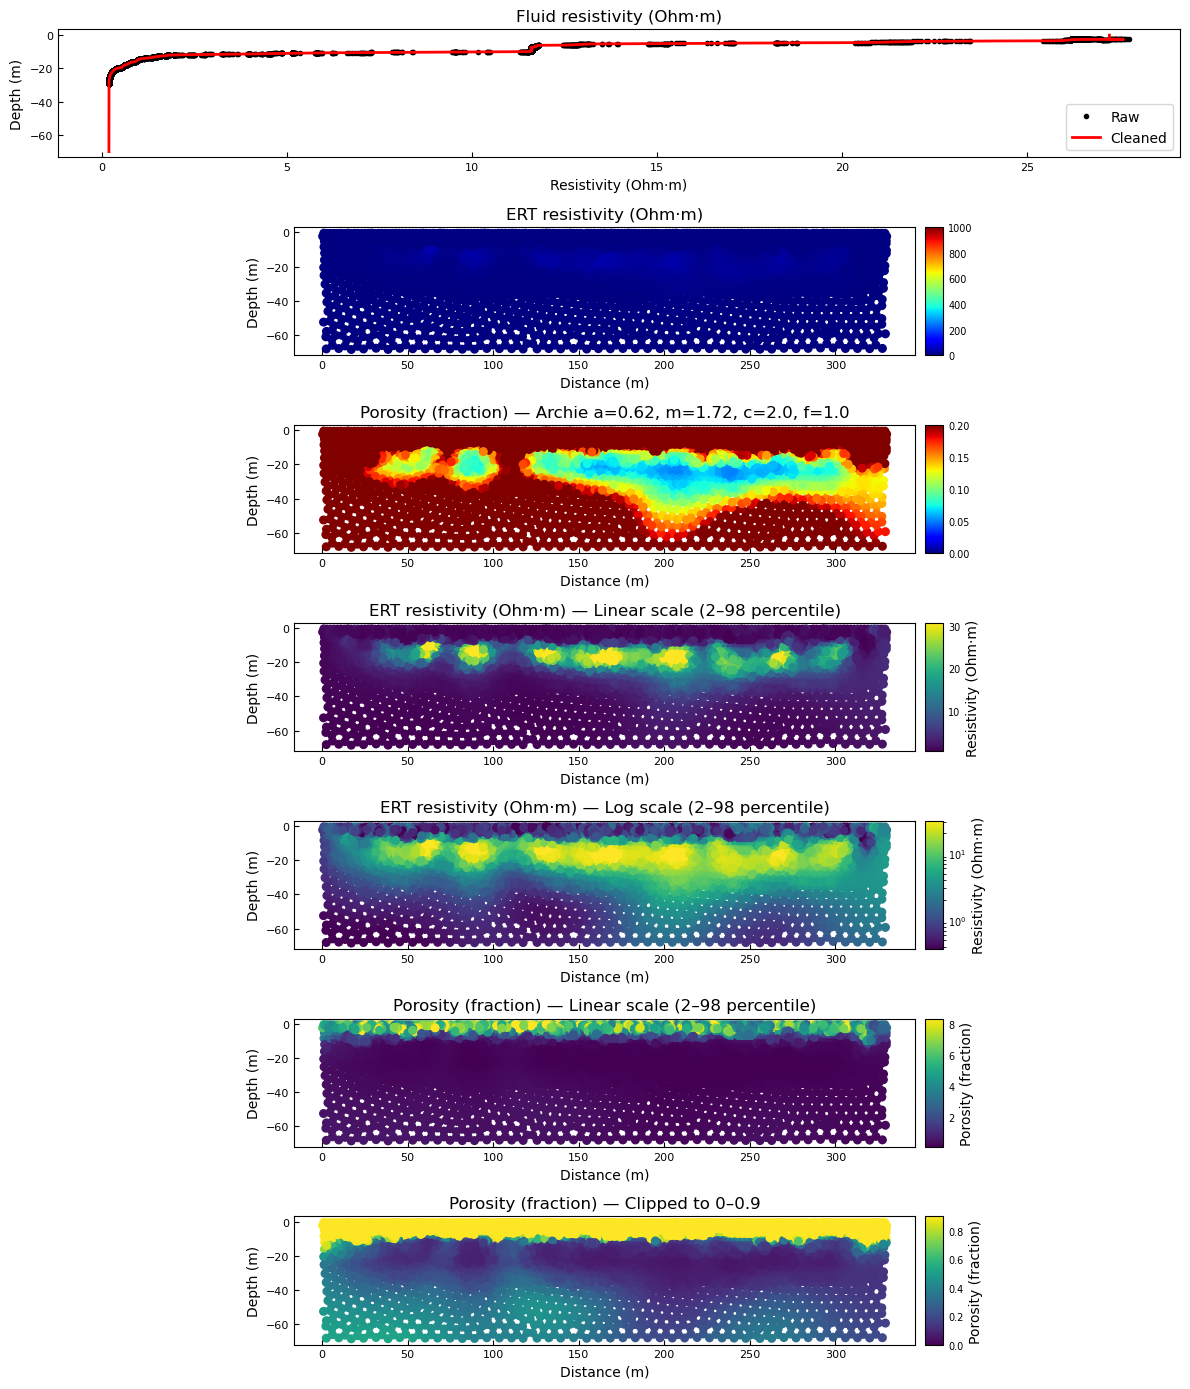

In [3]:
archie_bahamas = ArchieParams(
    a=0.62,
    m=1.72,
    c=2.0,
    f=1.0,
)

x, z, ert_res, phi = calc_porosity_section(
    well_log_path="LRS69_D_YSI_20230818.csv",
    vadose_thickness=2.5,
    resipy_dat_path="f001_res.dat",
    archie=archie_bahamas,
    plot=True,
)

In [4]:
def run_porosity_experiments(cases):
    results = []

    for case in cases:
        x, z, ert_res, phi = calc_porosity_section(
            well_log_path=case["well_log_path"],
            vadose_thickness=case["vadose_thickness"],
            resipy_dat_path=case["resipy_dat_path"],
            archie=case["archie"],
            plot=case.get("plot", True),
        )

        results.append({
            "name": case["name"],
            "x": x,
            "z": z,
            "ert_res": ert_res,
            "phi": phi,
            "archie": case["archie"],
        })

    return results

In [5]:
cases = [
    {
        "name": "Well_LRS69__T54__Archie_ref1",
        "well_log_path": "LRS69_D_YSI_20230818.csv",
        "vadose_thickness": 2.0,
        "resipy_dat_path": "f001_res.dat",
        "archie": ArchieParams(a=0.62, m=1.72, c=2.0, f=1.0),
        "plot": True,
    },
    {
        "name": "Well_LRS69__T54__Archie_ref2",
        "well_log_path": "LRS69_D_YSI_20230818.csv",
        "vadose_thickness": 2.0,
        "resipy_dat_path": "f001_res.dat",
        "archie": ArchieParams(a=1.00, m=2.00, c=2.0, f=1.0),
        "plot": True,
    },
]

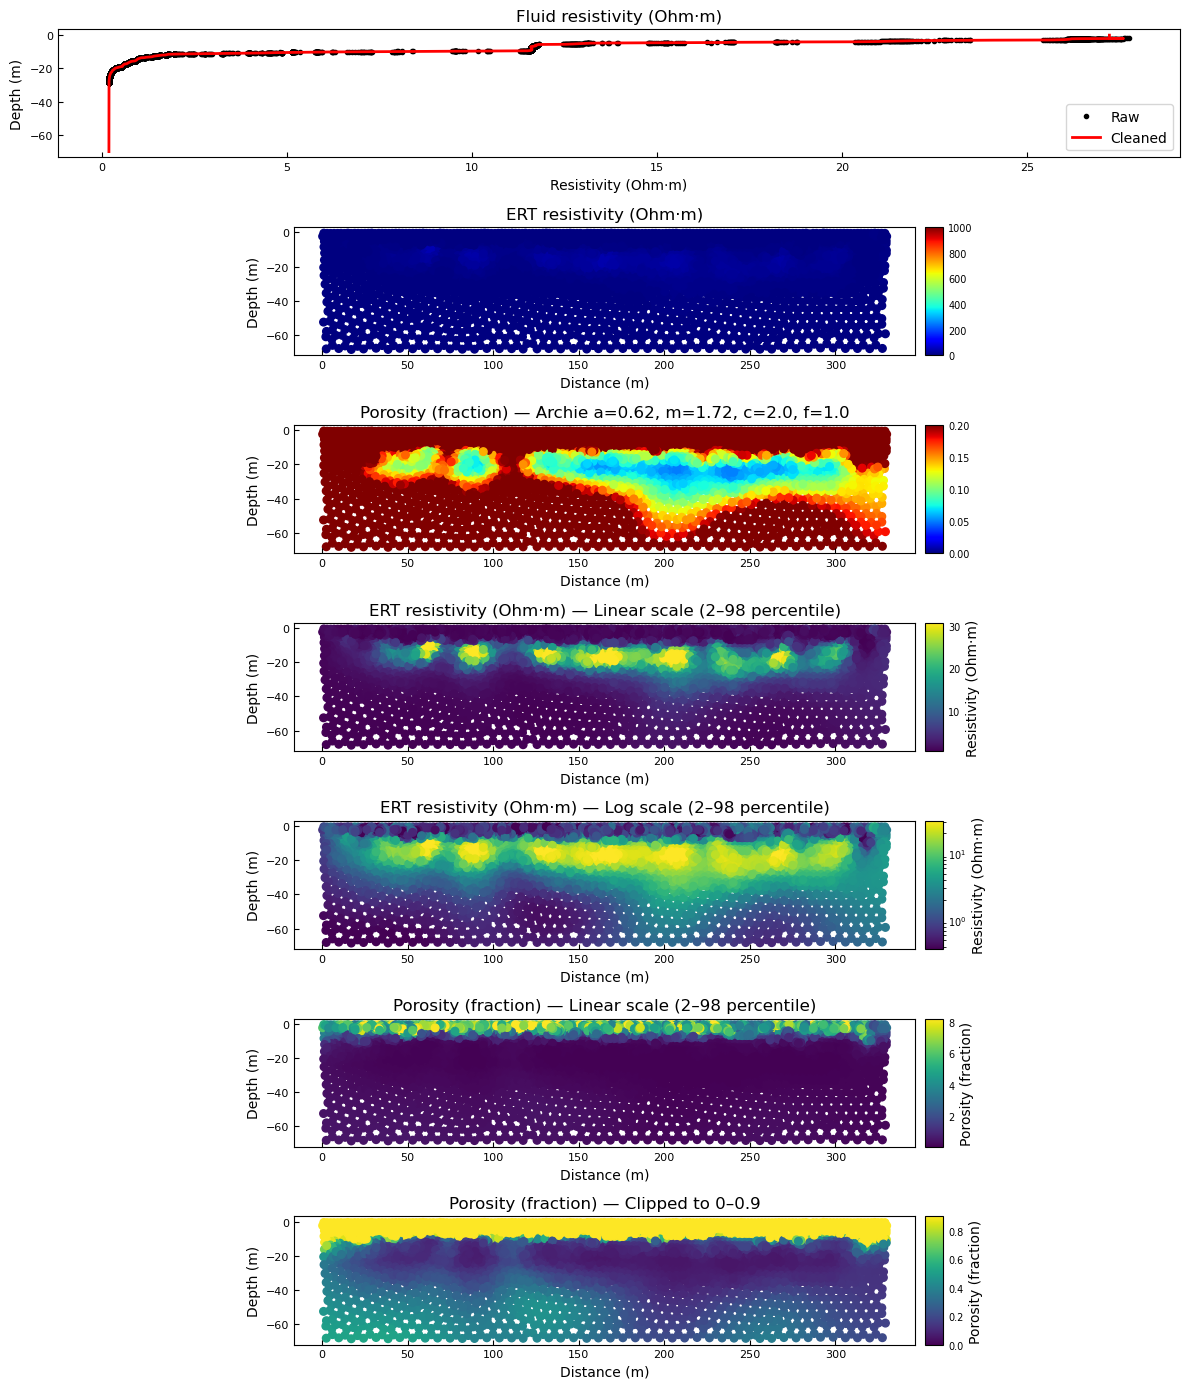

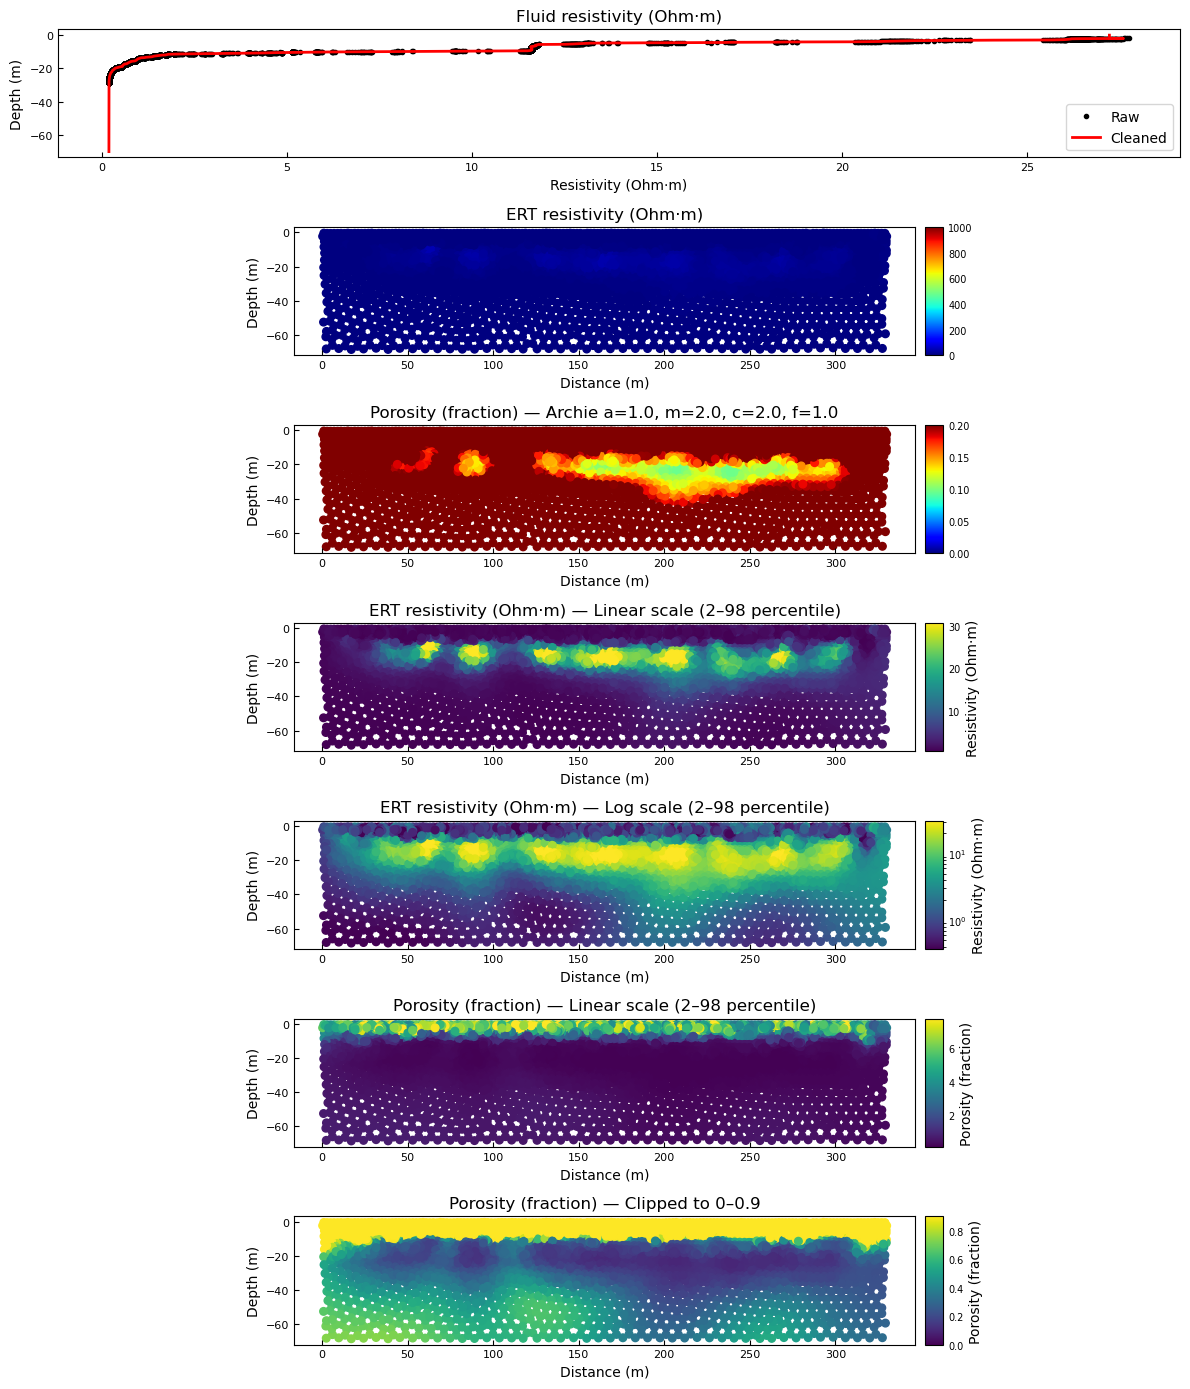

In [6]:
results= run_porosity_experiments(cases)